<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/Loan_data_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib as plt

In [ ]:
df = pd.read_csv("loan_data.csv")
df = df[df['person_age'] <= 80]
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44991 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44991 non-null  float64
 1   person_gender                   44991 non-null  object 
 2   person_education                44991 non-null  object 
 3   person_income                   44991 non-null  float64
 4   person_emp_exp                  44991 non-null  int64  
 5   person_home_ownership           44991 non-null  object 
 6   loan_amnt                       44991 non-null  float64
 7   loan_intent                     44991 non-null  object 
 8   loan_int_rate                   44991 non-null  float64
 9   loan_percent_income             44991 non-null  float64
 10  cb_person_cred_hist_length      44991 non-null  float64
 11  credit_score                    44991 non-null  int64  
 12  previous_loan_defaults_on_file  44991

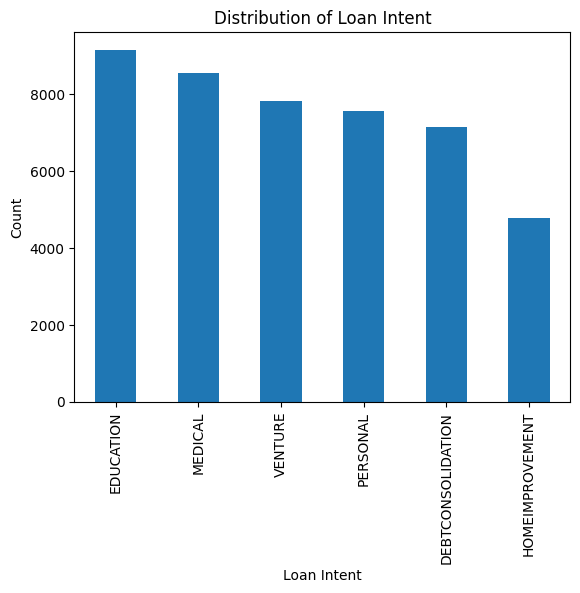

In [ ]:
loan_intent_counts = df['loan_intent'].value_counts()
loan_intent_counts.plot(kind='bar')
plt.pyplot.title('Distribution of Loan Intent')
plt.pyplot.xlabel('Loan Intent')
plt.pyplot.ylabel('Count')
plt.pyplot.show()

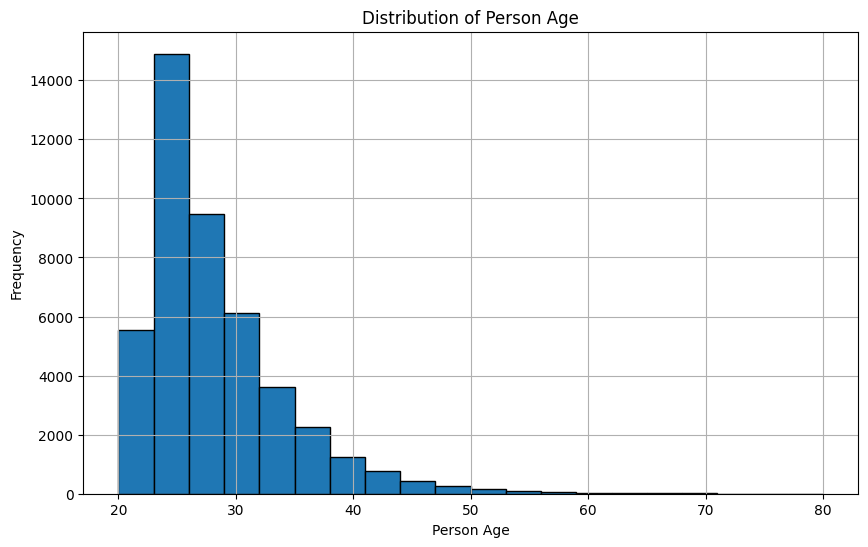

In [ ]:
plt.pyplot.figure(figsize=(10, 6))
plt.pyplot.hist(df['person_age'], bins=20, edgecolor='black')
plt.pyplot.title('Distribution of Person Age')
plt.pyplot.xlabel('Person Age')
plt.pyplot.ylabel('Frequency')
plt.pyplot.grid(True)
plt.pyplot.show()

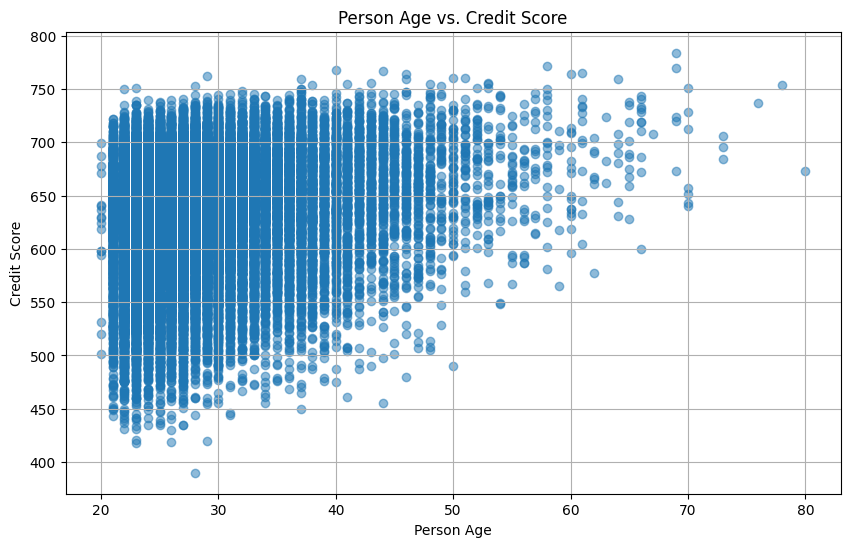

In [ ]:
plt.pyplot.figure(figsize=(10, 6))
plt.pyplot.scatter(df['person_age'], df['credit_score'], alpha=0.5)
plt.pyplot.title('Person Age vs. Credit Score')
plt.pyplot.xlabel('Person Age')
plt.pyplot.ylabel('Credit Score')
plt.pyplot.grid(True)
plt.pyplot.show()

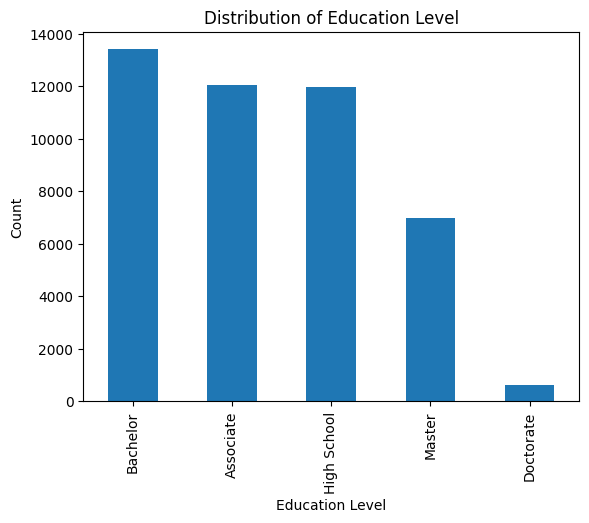

In [ ]:
education_counts = df['person_education'].value_counts()
education_counts.plot(kind='bar')
plt.pyplot.title('Distribution of Education Level')
plt.pyplot.xlabel('Education Level')
plt.pyplot.ylabel('Count')
plt.pyplot.show()

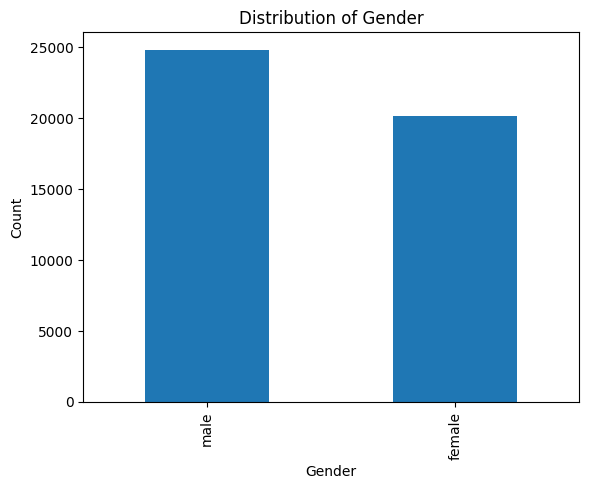

In [ ]:
gender_counts = df['person_gender'].value_counts()
gender_counts.plot(kind='bar')
plt.pyplot.title('Distribution of Gender')
plt.pyplot.xlabel('Gender')
plt.pyplot.ylabel('Count')
plt.pyplot.show()

# Task
Plot the proportion of loan defaults by age group.

## Define age groups

### Subtask:
Create bins or categories for different age ranges.


**Reasoning**:
Define the age bin boundaries and labels for the age groups based on the distribution of person_age.



In [ ]:
age_bins = [0, 25, 35, 45, 55, 65, 80]
age_labels = ['0-25', '26-35', '36-45', '46-55', '56-65', '66-80']

## Assign age groups

### Subtask:
Create a new column in the DataFrame to assign each person to an age group based on their age.


**Reasoning**:
Create a new column 'age_group' in the DataFrame by categorizing the 'person_age' column using the defined bins and labels.



In [ ]:
df['age_group'] = pd.cut(df['person_age'], bins=age_bins, labels=age_labels, right=False)
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,age_group
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,0-25
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,0-25
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,26-35
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1,0-25
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1,0-25


## Group by age group and loan status

### Subtask:
Group the data by the new age group column and the 'loan_status' column.


**Reasoning**:
Group the DataFrame by 'age_group' and 'loan_status' and count the occurrences in each group.



In [ ]:
grouped_data = df.groupby(['age_group', 'loan_status']).size().unstack(fill_value=0)
grouped_data

/tmp/ipython-input-3769027321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby(['age_group', 'loan_status']).size().unstack(fill_value=0)


loan_status,0,1
age_group,,
0-25,12180,3754
26-35,18620,5113
36-45,3509,927
46-55,555,161
56-65,95,37
66-80,31,8


## Calculate loan status proportions

### Subtask:
Calculate the proportion of loans that are defaulted (loan_status = 1) within each age group.


**Reasoning**:
Calculate the total number of loans and the proportion of defaulted loans for each age group based on the grouped data.



In [ ]:
grouped_data['total_loans'] = grouped_data[0] + grouped_data[1]
grouped_data['default_proportion'] = grouped_data[1] / grouped_data['total_loans']
display(grouped_data)

loan_status,0,1,total_loans,default_proportion
age_group,,,,
0-25,12180,3754,15934,0.235597
26-35,18620,5113,23733,0.215438
36-45,3509,927,4436,0.208972
46-55,555,161,716,0.224860
56-65,95,37,132,0.280303
66-80,31,8,39,0.205128


## Visualize the proportions

### Subtask:
Create a bar chart or other suitable plot to visualize the proportion of loan defaults for each age group.


**Reasoning**:
Create a bar chart to visualize the proportion of loan defaults by age group using the 'default_proportion' column of the `grouped_data` DataFrame, and add titles and labels for clarity.



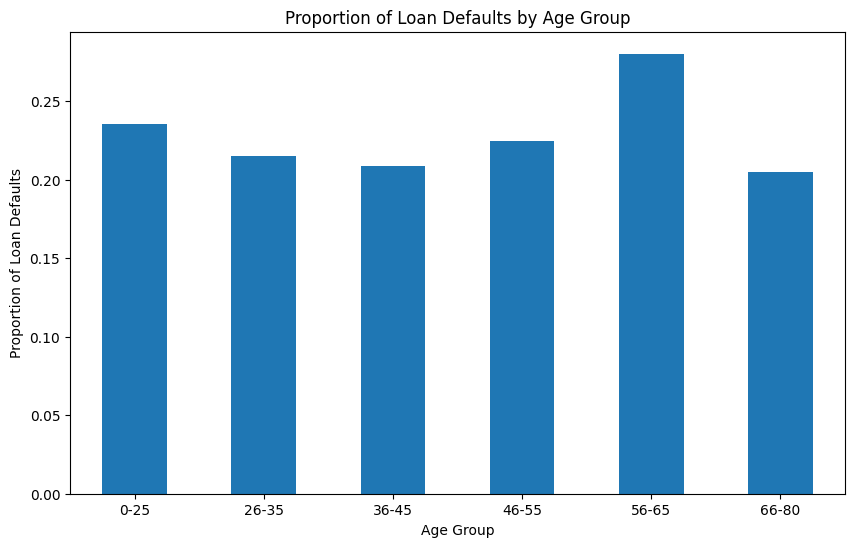

In [ ]:
plt.pyplot.figure(figsize=(10, 6))
grouped_data['default_proportion'].plot(kind='bar')
plt.pyplot.title('Proportion of Loan Defaults by Age Group')
plt.pyplot.xlabel('Age Group')
plt.pyplot.ylabel('Proportion of Loan Defaults')
plt.pyplot.xticks(rotation=0)
plt.pyplot.show()

## Summary:

### Data Analysis Key Findings

* The data was grouped into age bins: '0-25', '26-35', '36-45', '46-55', '56-65', and '66-80'.
* The proportion of defaulted loans was calculated for each age group by dividing the count of defaulted loans (loan\_status = 1) by the total number of loans in that group.
* A bar chart was generated to visualize the proportion of loan defaults across the defined age groups.

### Insights or Next Steps

* Analyze the bar chart to identify which age groups have the highest and lowest proportions of loan defaults.
* Consider exploring other factors that might contribute to the differences in default rates among age groups, such as income, employment status, or loan purpose.
